# Logistic Regression Model

In [48]:
# import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# load the dataset

df = pd.read_csv("customer_churn.csv")
df

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
...,...,...,...,...,...,...,...,...,...,...,...
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1


In [50]:
# top rows

df.head()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1


In [51]:
# last rows

df.tail()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
995,60,56292.986659,751.728246,26,149.322171,120,93,4,Male,West,0
996,64,36687.617333,556.297594,40,44.289513,172,3,4,Male,South,1
997,62,43438.125495,698.504304,33,132.459634,3,52,2,Male,East,0
998,35,60835.720367,607.589743,49,72.489390,341,74,3,Male,West,1
999,55,44407.502719,770.356453,36,104.107070,127,60,4,Female,South,1


In [52]:
# statistical summary

df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


In [53]:
# information of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   object 
 9   region                 1000 non-null   object 
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 86.1+ KB


In [54]:
# shape of the dataset

df.shape

(1000, 11)

In [55]:
# 

df.isnull().sum()

age                       0
income                   49
credit_score             50
transactions_month        0
avg_purchase_value       50
days_since_last_login     0
tenure_months             0
num_products              0
gender                    0
region                    0
churn                     0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='credit_score'>

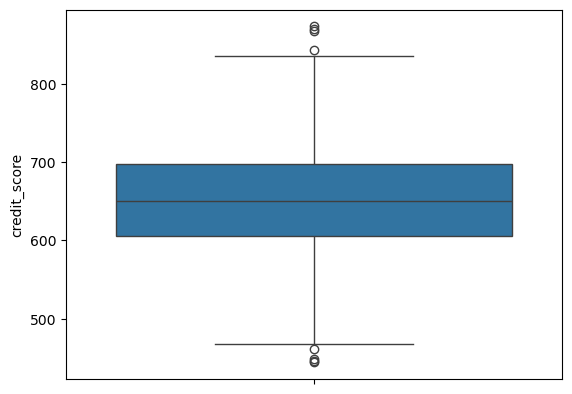

In [57]:
# make the box plot (for checking the outliers)

sns.boxplot(df["credit_score"])

In [58]:
# data preprocessing 

# handle the missing value using median of all num columns


# income_median

# handel the misssin value in the columns usingg the medium

# income column
income_median=df["income"].median()
income_median=round(income_median,2)

# credit_ccore column 
credit_score_median=df['credit_score'].median()
credit_score_median=round(credit_score_median,2)

# transactions_month column

# avg_purchase_value column
avg_purchase_value_median=df["avg_purchase_value"].median()
avg_purchase_value_median=round(avg_purchase_value_median,2)

# handel the missing values
# credit score
df["credit_score"]=df["credit_score"].fillna(credit_score_median)
# income column
df["income"]=df["income"].fillna(income_median)
# avg_purchase_value
df["avg_purchase_value"]=df["avg_purchase_value"].fillna(avg_purchase_value_median)

In [59]:
df.isnull().sum()

age                      0
income                   0
credit_score             0
transactions_month       0
avg_purchase_value       0
days_since_last_login    0
tenure_months            0
num_products             0
gender                   0
region                   0
churn                    0
dtype: int64

In [60]:
# handle the outliers

num_columns=df.select_dtypes(include=["number"]).columns


for col in num_columns:

    #find the Q1 and Q3

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # find the IQR

    IQR = Q3 - Q1

    # find the upper bound and lower bound

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 *IQR


    # find the ouliers

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
outliers


,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn


<Axes: >

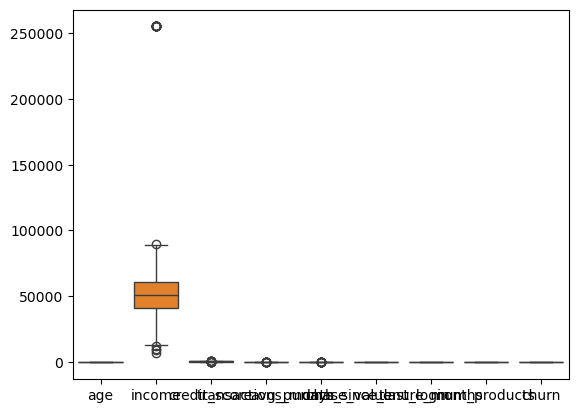

In [61]:
sns.boxplot(df)

In [62]:
# handle the cat columns

df["gender"].replace({"Male":1,"Female":0},inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_26844\1574865749.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].replace({"Male":1,"Female":0},inplace=True)
C:\Users\Shree\AppData\Local\Temp\ipykernel_26844\1574865749.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"].repl

In [63]:
# drop the column

df.drop("region",axis=True,inplace = True)

In [64]:
# Divide into X and y 


X = df.drop("churn",axis = 1)
y = df["churn"]

In [ ]:
# model builiding

from sklearn.linear_model import LogisticRegression

LR=LogisticRegression()

# train the model
model=LR.fit(X_train,y_train)

# ?prediction on testing
y_pred=model.predict(X_test)

c:\Users\Shree\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
# moedel evalulation

from sklearn.metrics import accuracy_score

# ?find aaccuracy

ac=accuracy_score(y_test,y_pred)
print("Accuracy model, ",ac)

Accuracy model,  0.53
